<a href="https://colab.research.google.com/github/nevita275/ML_20_Nevita/blob/main/JS05/JS05-Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS 2

In [1]:
# Upload Data

from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [3]:
# Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load data dan bersihkan

df = pd.read_csv('spam.csv', encoding='latin-1')

df = df.drop(df.iloc[:, 2:], axis=1)
df.columns = ['Labels', 'SMS']

print(df['Labels'].value_counts())
df.head()

Labels
ham     4825
spam     747
Name: count, dtype: int64


,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Encoding label dan split data

df['Labels'] = df['Labels'].map({'spam': 1, 'ham': 0})

X = df['SMS'].values
y = df['Labels'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)
print(len(X_train), len(X_test))

4457 1115


## Soal 1: Multinomial NB + CountVectorizer (stop_words aktif)
### 1a. Buat CountVectorizer dengan stop_words

In [6]:
bow = CountVectorizer(stop_words='english')

### 1b. Mengubah teks menjadi vektor

In [7]:
X_train_bow = bow.fit_transform(X_train)   # fit + transform pada training
X_test_bow = bow.transform(X_test)         # hanya transform pada testing

print('Jumlah kosakata:', len(bow.get_feature_names_out()))
print('Dimensi training:', X_train_bow.shape)

Jumlah kosakata: 7466
Dimensi training: (4457, 7466)


### 1c. Training model

In [8]:
mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

MultinomialNB()

### 1d. Prediksi dan hitung akurasi

In [9]:
pred_train_bow = mnb_bow.predict(X_train_bow)
pred_test_bow = mnb_bow.predict(X_test_bow)

acc_train_bow = accuracy_score(y_train, pred_train_bow)
acc_test_bow = accuracy_score(y_test, pred_test_bow)

print(f'Akurasi train: {acc_train_bow}')
print(f'Akurasi test : {acc_test_bow}')

Akurasi train: 0.9946152120260264
Akurasi test : 0.9829596412556054


1e. Evaluasi lengkap

In [10]:
print(confusion_matrix(y_test, pred_test_bow))
print(classification_report(y_test, pred_test_bow, target_names=['ham', 'spam']))

[[951   3]
 [ 16 145]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       954
        spam       0.98      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## Soal 2: Multinomial NB + TF-IDF (stop_words aktif)
### 2a. Membuat TfidfVectorizer dengan stop_words

In [11]:
tfidf = TfidfVectorizer(stop_words='english')

### 2b. Ubah teks menjadi vektor

In [12]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Jumlah kosakata:', len(tfidf.get_feature_names_out()))
print('Dimensi training:', X_train_tfidf.shape)

Jumlah kosakata: 7466
Dimensi training: (4457, 7466)


### 2c. Training model

In [13]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

### 2d. Prediksi dan hitung akurasi

In [14]:
pred_train_tfidf = mnb_tfidf.predict(X_train_tfidf)
pred_test_tfidf = mnb_tfidf.predict(X_test_tfidf)

acc_train_tfidf = accuracy_score(y_train, pred_train_tfidf)
acc_test_tfidf = accuracy_score(y_test, pred_test_tfidf)

print(f'Akurasi train: {acc_train_tfidf}')
print(f'Akurasi test : {acc_test_tfidf}')

Akurasi train: 0.9842943684092439
Akurasi test : 0.9605381165919282


### 2e. Evaluasi lengkap

In [15]:
print(confusion_matrix(y_test, pred_test_tfidf))
print(classification_report(y_test, pred_test_tfidf, target_names=['ham', 'spam']))

[[954   0]
 [ 44 117]]
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       954
        spam       1.00      0.73      0.84       161

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



## Perbandingan dan kesimpulan
### Tabel Perbandingan

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

def ringkas(nama, y_true, y_pred, acc_train):
    return {
        'Fitur': nama,
        'Akurasi train': acc_train,
        'Akurasi test': accuracy_score(y_true, y_pred),
        'Precision (spam)': precision_score(y_true, y_pred),
        'Recall (spam)': recall_score(y_true, y_pred),
        'F1 (spam)': f1_score(y_true, y_pred),
    }

hasil = pd.DataFrame([
    ringkas('CountVectorizer', y_test, pred_test_bow, acc_train_bow),
    ringkas('TF-IDF', y_test, pred_test_tfidf, acc_train_tfidf),
]).set_index('Fitur').round(4)

hasil

,Akurasi train,Akurasi test,Precision (spam),Recall (spam),F1 (spam)
Fitur,,,,,
CountVectorizer,0.9946,0.9830,0.9797,0.9006,0.9385
TF-IDF,0.9843,0.9605,1.0000,0.7267,0.8417


### Grafik Perbandingan

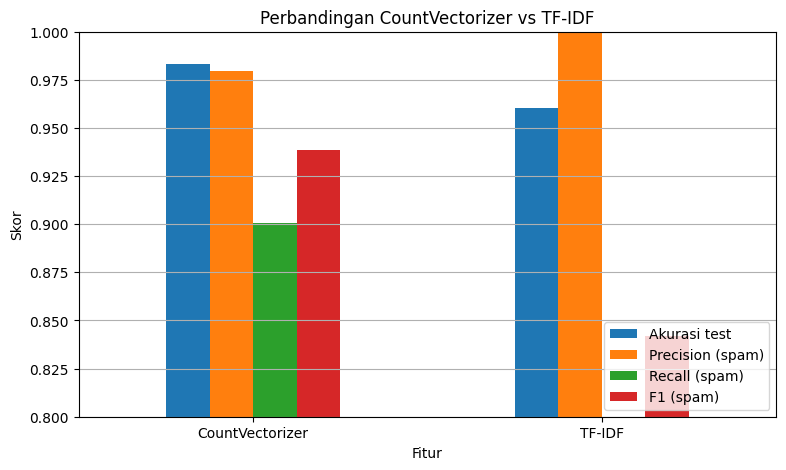

In [17]:
hasil[['Akurasi test', 'Precision (spam)', 'Recall (spam)', 'F1 (spam)']].plot(
    kind='bar', figsize=(9, 5), rot=0)
plt.title('Perbandingan CountVectorizer vs TF-IDF')
plt.ylabel('Skor')
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.show()

## Kesimpulan:
Pada Tugas 1, model Multinomial Naive Bayes dengan fitur CountVectorizer (stop_words aktif) menghasilkan akurasi training 99,46% dan akurasi testing 98,30%. Untuk kelas spam, precision 97,97%, recall 90,06%, dan F1-score 93,85%. Dari 161 SMS spam pada data testing, 145 berhasil dideteksi dan 16 lolos, sedangkan hanya 3 SMS ham yang salah dianggap spam.

Pada Tugas 2, model dengan fitur TF-IDF (stop_words aktif) menghasilkan akurasi training 98,43% dan akurasi testing 96,05%. Precision spam mencapai 100%, tetapi recall spam hanya 72,67% dan F1-score 84,17%. Sebanyak 44 SMS spam lolos terdeteksi sebagai ham, dan tidak ada ham yang salah dianggap spam.

Berdasarkan perbandingan tersebut, fitur CountVectorizer adalah yang terbaik untuk data spam.csv. Akurasi testing-nya lebih tinggi (98,30% dibanding 96,05%), dan F1-score spam-nya jauh lebih baik (93,85% dibanding 84,17%) karena recall-nya jauh lebih tinggi. TF-IDF memang tidak pernah salah menuduh pesan normal sebagai spam, tetapi ia melewatkan hampir 27% pesan spam, padahal tujuan utama model ini adalah menangkap spam.